# SHAP pipeline

For each tract, get feature contributions to **P_CANCER** and **P_RESP**.
Uses `../.data/analysis_minimal.csv` (run **build_analysis_minimal** notebook first).

**Outputs:** `../.data/tract_shap.csv`, `../.data/shap_importance.csv`

In [2]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import shap
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split

data_dir = Path("../.data")
minimal_csv = data_dir / "analysis_minimal.csv"

# EJSCREEN minimal + EJI 2024 indices (from build_analysis_minimal with EJI join)
feature_columns = [
    "P_PM25",
    "P_OZONE",
    "P_DSLPM",
    "P_PTRAF",
    "P_LDPNT",
    "P_PNPL",
    "P_PRMP",
    "P_PTSDF",
    "P_UST",
    "P_PWDIS",
    "DEMOGIDX_2",
    # EJI 2024 (percentiles 0–1; optional if analysis_minimal has no EJI join)
    "RPL_EJI",
    "RPL_SER",
    "RPL_SVM",
    "RPL_EBM",
    "RPL_EJI_CBM",
]

In [4]:
if not minimal_csv.exists():
    raise FileNotFoundError(
        f"Run build_analysis_minimal notebook first to create {minimal_csv}"
    )

df = pd.read_csv(minimal_csv)
available = [c for c in feature_columns if c in df.columns]
missing = set(feature_columns) - set(available)
if missing:
    print(f"Using {len(available)} features (missing, skipped: {missing})")
else:
    print(f"Using all {len(available)} features")

# Drop rows with NaN in features or outcomes (e.g. EJI left-join misses)
outcome_cols = [c for c in ["P_CANCER", "P_RESP"] if c in df.columns]
need_complete = available + outcome_cols
n_before = len(df)
df = df.dropna(subset=need_complete).reset_index(drop=True)
n_dropped = n_before - len(df)
if n_dropped:
    print(
        f"Dropped {n_dropped:,} rows with NaN in features/outcomes (no NaNs in model data)"
    )

X = df[available]
id_cols = df[["ID", "ST_ABBREV", "CNTY_NAME"]].copy()
print(f"Loaded {len(df):,} tracts")

Using all 16 features
Dropped 872 rows with NaN in features/outcomes (no NaNs in model data)
Loaded 80,129 tracts


In [5]:
# Subsample for faster SHAP (set to None to use full data)
max_rows = 100_000
if len(df) > max_rows:
    idx, _ = train_test_split(
        df.index, train_size=max_rows, random_state=42, stratify=df["ST_ABBREV"]
    )
    df = df.loc[idx].reset_index(drop=True)
    X = df[available]
    id_cols = df[["ID", "ST_ABBREV", "CNTY_NAME"]].copy()
    print(f"Using subsample of {len(df):,} tracts (max_rows={max_rows})")

## Train models and compute SHAP per outcome

In [6]:
# Ensure no NaN in features or outcomes (model requires finite values)
outcome_cols = [c for c in ["P_CANCER", "P_RESP"] if c in df.columns]
need_ok = available + outcome_cols
ok = df[need_ok].dropna(how="any").index
if len(ok) < len(df):
    print(f"Dropping {len(df) - len(ok):,} rows with NaN in features/outcomes.")
df = df.loc[ok].reset_index(drop=True)
X = df[available]
id_cols = id_cols.loc[ok].reset_index(drop=True)

results = []

for outcome_name, outcome_col in [("cancer", "P_CANCER"), ("resp", "P_RESP")]:
    if outcome_col not in df.columns:
        continue
    y = df[outcome_col]
    print(f"--- {outcome_col} ---")
    model = GradientBoostingRegressor(
        n_estimators=100, max_depth=4, min_samples_leaf=20, random_state=42
    )
    model.fit(X, y)
    print(f"  R² (train): {model.score(X, y):.4f}")
    id_cols[f"pred_{outcome_name}"] = model.predict(X)
    explainer = shap.TreeExplainer(model, X)
    shap_vals = explainer.shap_values(X)
    for i, feat in enumerate(available):
        results.append(
            {
                "outcome": outcome_name,
                "feature": feat,
                "mean_abs_shap": float(pd.Series(shap_vals[:, i]).abs().mean()),
            }
        )
        id_cols[f"shap_{outcome_name}_{feat}"] = shap_vals[:, i]
    print("  SHAP done.")

--- P_CANCER ---
  R² (train): 0.4672


100%|===================| 79911/80129 [01:34<00:00]        

  SHAP done.
--- P_RESP ---
  R² (train): 0.5722


 99%|===================| 79568/80129 [01:25<00:00]        

  SHAP done.


In [7]:
out = id_cols.copy()
shap_cols = [c for c in out.columns if c.startswith("shap_")]

# Top-3 driver columns per outcome
for outcome_name in ["cancer", "resp"]:
    cols = [c for c in shap_cols if c.startswith(f"shap_{outcome_name}_")]
    if not cols:
        continue
    feat_order = [c.replace(f"shap_{outcome_name}_", "") for c in cols]
    vals = out[cols].values
    abs_vals = np.abs(vals)
    rank_order = abs_vals.argsort(axis=1)[:, ::-1]
    for r in range(3):
        out[f"top_{outcome_name}_{r+1}_feature"] = [
            feat_order[rank_order[i, r]] for i in range(len(out))
        ]
        out[f"top_{outcome_name}_{r+1}_shap"] = [
            vals[i, rank_order[i, r]] for i in range(len(out))
        ]

## Visualize regression output

Actual vs predicted and residuals for P_CANCER and P_RESP (same rows as `out` / `id_cols`).

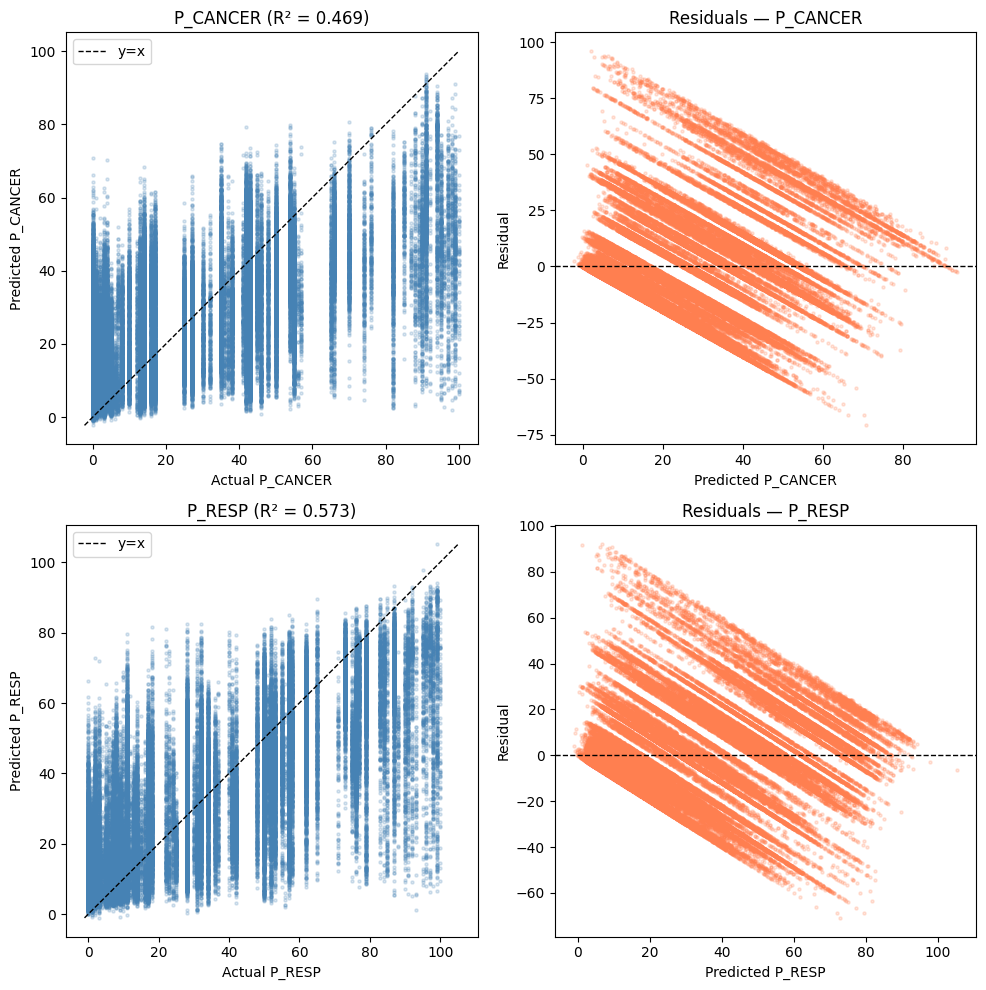

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for i, (outcome_name, outcome_col) in enumerate(
    [("cancer", "P_CANCER"), ("resp", "P_RESP")]
):
    if outcome_col not in df.columns or f"pred_{outcome_name}" not in out.columns:
        continue
    actual = df[outcome_col].values
    pred = out[f"pred_{outcome_name}"].values
    res = actual - pred

    # Actual vs predicted
    ax = axes[i, 0]
    ax.scatter(actual, pred, alpha=0.2, s=5, c="steelblue")
    mn = min(actual.min(), pred.min())
    mx = max(actual.max(), pred.max())
    ax.plot([mn, mx], [mn, mx], "k--", lw=1, label="y=x")
    ax.set_xlabel(f"Actual {outcome_col}")
    ax.set_ylabel(f"Predicted {outcome_col}")
    r2 = np.corrcoef(actual, pred)[0, 1] ** 2
    ax.set_title(f"{outcome_col} (R² = {r2:.3f})")
    ax.legend()
    ax.set_aspect("equal")

    # Residuals vs predicted
    ax = axes[i, 1]
    ax.scatter(pred, res, alpha=0.2, s=5, c="coral")
    ax.axhline(0, color="k", ls="--", lw=1)
    ax.set_xlabel(f"Predicted {outcome_col}")
    ax.set_ylabel("Residual")
    ax.set_title(f"Residuals — {outcome_col}")

plt.tight_layout()
plt.show()

In [9]:
importance_df = pd.DataFrame(results)
importance_wide = importance_df.pivot(
    index="feature", columns="outcome", values="mean_abs_shap"
).reset_index()
importance_wide.to_csv(data_dir / "shap_importance.csv", index=False)
print("Saved", data_dir / "shap_importance.csv")

out.to_csv(data_dir / "tract_shap.csv", index=False)
print(f"Saved tract-level SHAP -> {data_dir / 'tract_shap.csv'} ({len(out):,} rows)")

Saved ../.data/shap_importance.csv
Saved tract-level SHAP -> ../.data/tract_shap.csv (80,129 rows)


In [10]:
importance_wide

outcome,feature,cancer,resp
0,DEMOGIDX_2,0.935360,1.271763
1,P_DSLPM,5.468503,9.555856
2,P_LDPNT,0.714694,0.338630
3,P_OZONE,2.839382,1.243047
4,P_PM25,5.628851,6.380718
5,P_PNPL,0.762284,1.135419
6,P_PRMP,0.731728,0.558218
7,P_PTRAF,0.540444,0.479212
8,P_PTSDF,0.220515,0.230258
9,P_PWDIS,1.034154,0.567389


In [11]:
out.head(10)

,ID,ST_ABBREV,CNTY_NAME,pred_cancer,shap_cancer_P_PM25,shap_cancer_P_OZONE,shap_cancer_P_DSLPM,shap_cancer_P_PTRAF,shap_cancer_P_LDPNT,shap_cancer_P_PNPL,...,top_cancer_2_feature,top_cancer_2_shap,top_cancer_3_feature,top_cancer_3_shap,top_resp_1_feature,top_resp_1_shap,top_resp_2_feature,top_resp_2_shap,top_resp_3_feature,top_resp_3_shap
0,1001020100,AL,Autauga,31.598813,7.198058,0.984014,-0.237760,0.611295,-0.525404,0.737103,...,RPL_EBM,-3.913382,P_PWDIS,1.204955,P_PM25,7.433565,P_DSLPM,-4.507769,RPL_EBM,-2.871570
1,1001020200,AL,Autauga,33.607012,6.853892,1.691649,0.864503,-0.506197,-0.533142,0.707900,...,RPL_EBM,-4.870107,P_OZONE,1.691649,P_PM25,8.643821,RPL_EBM,-4.137138,DEMOGIDX_2,2.643968
2,1001020300,AL,Autauga,34.397299,7.356477,0.966650,2.374576,-0.021611,0.413388,0.727643,...,RPL_EBM,-4.451039,P_DSLPM,2.374576,P_PM25,8.113985,RPL_EBM,-2.766353,P_DSLPM,1.288118
3,1001020400,AL,Autauga,31.789824,7.340478,1.429353,3.275093,-0.587786,0.264520,0.365400,...,RPL_EBM,-4.391749,P_DSLPM,3.275093,P_PM25,8.123332,P_DSLPM,5.502220,RPL_EBM,-2.825168
4,1001020501,AL,Autauga,37.099080,7.734970,1.137846,3.295311,-0.473916,-1.574111,0.423490,...,RPL_EBM,-4.520498,RPL_EJI_CBM,3.443496,P_PM25,8.519712,P_DSLPM,7.179643,RPL_EBM,-4.019678
5,1001020502,AL,Autauga,33.252111,7.743347,0.941846,3.085820,-0.548178,-1.436005,0.629203,...,RPL_EBM,-6.897442,P_DSLPM,3.085820,P_PM25,8.758706,P_DSLPM,7.066277,RPL_EBM,-6.046738
6,1001020503,AL,Autauga,33.904011,7.765528,0.576887,3.019722,-0.302321,1.181302,0.632620,...,P_PM25,7.765528,P_DSLPM,3.019722,P_PM25,8.489857,RPL_EBM,-7.187156,P_DSLPM,6.950162
7,1001020600,AL,Autauga,38.151258,7.122727,1.423476,0.980229,0.030320,0.136196,0.587093,...,P_OZONE,1.423476,P_PWDIS,1.201583,P_PM25,7.325761,P_DSLPM,-2.652878,P_PNPL,0.839372
8,1001020700,AL,Autauga,37.865897,8.421199,2.479563,2.179135,-0.449268,0.233365,0.296147,...,RPL_EBM,-4.135111,P_OZONE,2.479563,P_PM25,9.135561,RPL_EBM,-2.981834,P_DSLPM,2.706422
9,1001020801,AL,Autauga,23.669586,4.982175,0.976147,-4.935637,0.432467,0.294592,0.614988,...,P_DSLPM,-4.935637,RPL_EBM,-3.459275,P_DSLPM,-10.261908,P_PM25,6.328913,DEMOGIDX_2,-4.083178
